# 03 - Baseline CNN with PyTorch

This notebook trains a **basic CNN baseline** on **Dataset 1** using **PyTorch**.

## Workflow
1. Set paths and hyperparameters
2. Build datasets and dataloaders
3. Define a simple CNN
4. Train and validate
5. Save the best model
6. Evaluate on the test set
7. Export plots and reports


In [2]:
# Install packages if needed
# Run these in your .venv terminal first if required:
# pip uninstall -y tensorflow tensorflow-intel keras
# pip install torch torchvision torchaudio
# pip install pandas matplotlib scikit-learn pillow tqdm

In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.7.1+cu128
CUDA available: True
Device count: 1
Current device: 0
GPU name: NVIDIA GeForce RTX 2060


In [4]:
# Imports
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [5]:
# Optional: show Chinese labels correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [6]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [7]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "herb50_dataset_1" / "split_dataset"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
MODELS_DIR = PROJECT_ROOT / "models" / "cnn"

for p in [FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\train
VAL_DIR  : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\val
TEST_DIR : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\test


In [8]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
# Hyperparameters
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_WORKERS = 0   # Windows is safer with 0 in notebooks
PATIENCE = 4

In [10]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [11]:
# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 50
First 10 classes: ['乌梅', '侧柏叶', '北沙参块', '北沙参条', '半夏', '地龙', '夏枯草', '大血藤', '小茴香', '巴戟天']


In [12]:
# Save class mapping
class_mapping = pd.DataFrame({
    "class_id": list(range(len(class_names))),
    "class_name_cn": class_names
})
class_mapping_path = REPORTS_DIR / "pytorch_cnn_class_mapping.csv"
class_mapping.to_csv(class_mapping_path, index=False, encoding="utf-8-sig")
print("Saved:", class_mapping_path)
class_mapping.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\pytorch_cnn_class_mapping.csv


,class_id,class_name_cn
0,0,乌梅
1,1,侧柏叶
2,2,北沙参块
3,3,北沙参条
4,4,半夏


In [13]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 1557
Val batches  : 195
Test batches : 195


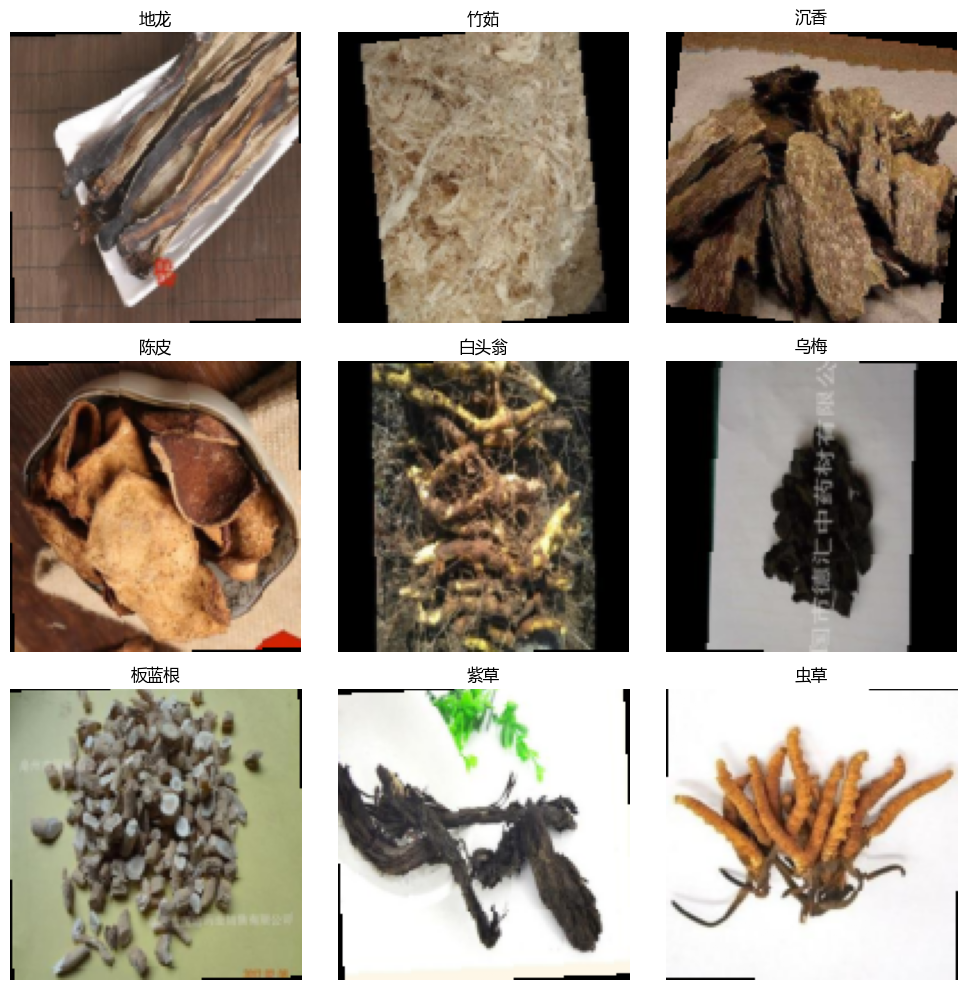

In [14]:
# Visualize a few training images
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Simple baseline CNN
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * (IMG_SIZE // 16) * (IMG_SIZE // 16), 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=num_classes).to(device)
model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=50, bias=True)
  )

In [16]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

In [17]:
# Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [18]:
# Train loop
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
best_model_path = MODELS_DIR / "baseline_cnn_pytorch_best.pth"

patience_counter = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 50)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", best_val_acc)
print("Best model saved to:", best_model_path)

Epoch 1/10


  0%|          | 0/1557 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 3.1552 | Train Acc: 0.1479
Val   Loss: 2.6412 | Val   Acc: 0.2551
Best model updated.
--------------------------------------------------
Epoch 2/10


  0%|          | 0/1557 [00:00<?, ?it/s]

...

  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 1.3489 | Train Acc: 0.5948
Val   Loss: 1.1706 | Val   Acc: 0.6590
Best model updated.
--------------------------------------------------
Epoch 10/10


  0%|          | 0/1557 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 1.2695 | Train Acc: 0.6182
Val   Loss: 1.1052 | Val   Acc: 0.6844
Best model updated.
--------------------------------------------------
Best validation accuracy: 0.6843880501124318
Best model saved to: I:\DeepLearning\ChineseHerb_Identify\models\cnn\baseline_cnn_pytorch_best.pth


In [19]:
# Save history
history_df = pd.DataFrame(history)
history_path = REPORTS_DIR / "baseline_cnn_pytorch_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved:", history_path)
history_df.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\baseline_cnn_pytorch_history.csv


,train_loss,train_acc,val_loss,val_acc
0,3.155163,0.147930,2.641227,0.255059
1,2.530959,0.286164,2.172569,0.377449
2,2.213600,0.362959,1.937523,0.447800
3,1.986277,0.420064,1.726839,0.500161
4,1.804548,0.471548,1.562561,0.547382


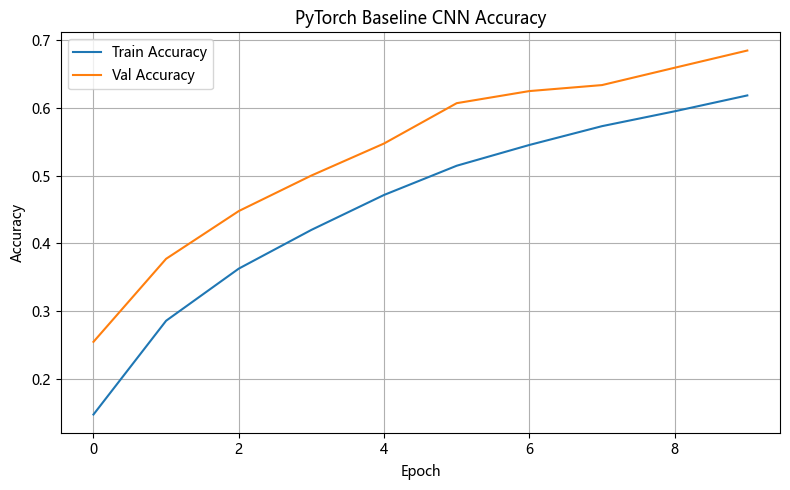

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\baseline_cnn_pytorch_accuracy.png


In [20]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.title("PyTorch Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_fig_path = FIGURES_DIR / "baseline_cnn_pytorch_accuracy.png"
plt.savefig(acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", acc_fig_path)

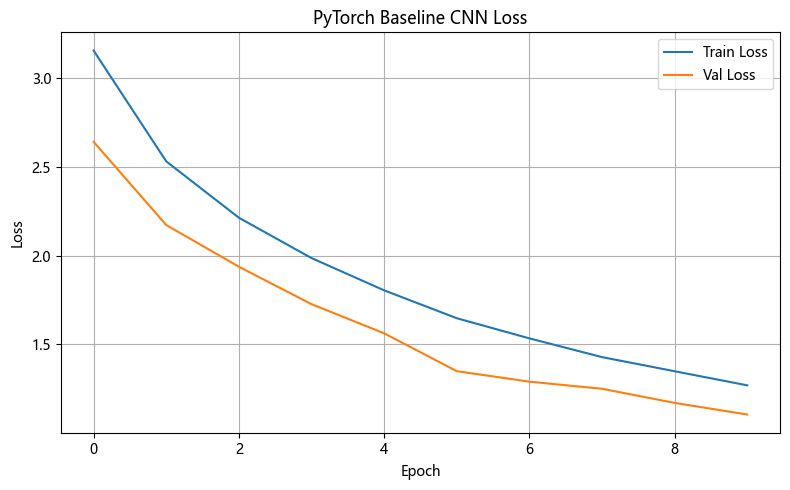

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\baseline_cnn_pytorch_loss.png


In [21]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("PyTorch Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = FIGURES_DIR / "baseline_cnn_pytorch_loss.png"
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", loss_fig_path)

In [22]:
# Load best weights before final test
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=50, bias=True)
  )

In [23]:
# Test evaluation
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

  0%|          | 0/195 [00:00<?, ?it/s]

Test Loss: 1.0599
Test Accuracy: 0.7012


In [24]:
# Classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_path = REPORTS_DIR / "baseline_cnn_pytorch_classification_report.csv"
report_df.to_csv(report_path, encoding="utf-8-sig")
print("Saved:", report_path)
report_df.head(10)

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\baseline_cnn_pytorch_classification_report.csv


,precision,recall,f1-score,support
乌梅,0.757576,0.819672,0.787402,122.0
侧柏叶,0.620155,0.714286,0.663900,112.0
北沙参块,0.637681,0.721311,0.676923,122.0
北沙参条,0.754237,0.809091,0.780702,110.0
半夏,0.707317,0.750000,0.728033,116.0
地龙,0.618182,0.778626,0.689189,131.0
夏枯草,0.693182,0.554545,0.616162,110.0
大血藤,0.854701,0.757576,0.803213,132.0
小茴香,0.744681,0.538462,0.625000,130.0
巴戟天,0.717172,0.510791,0.596639,139.0


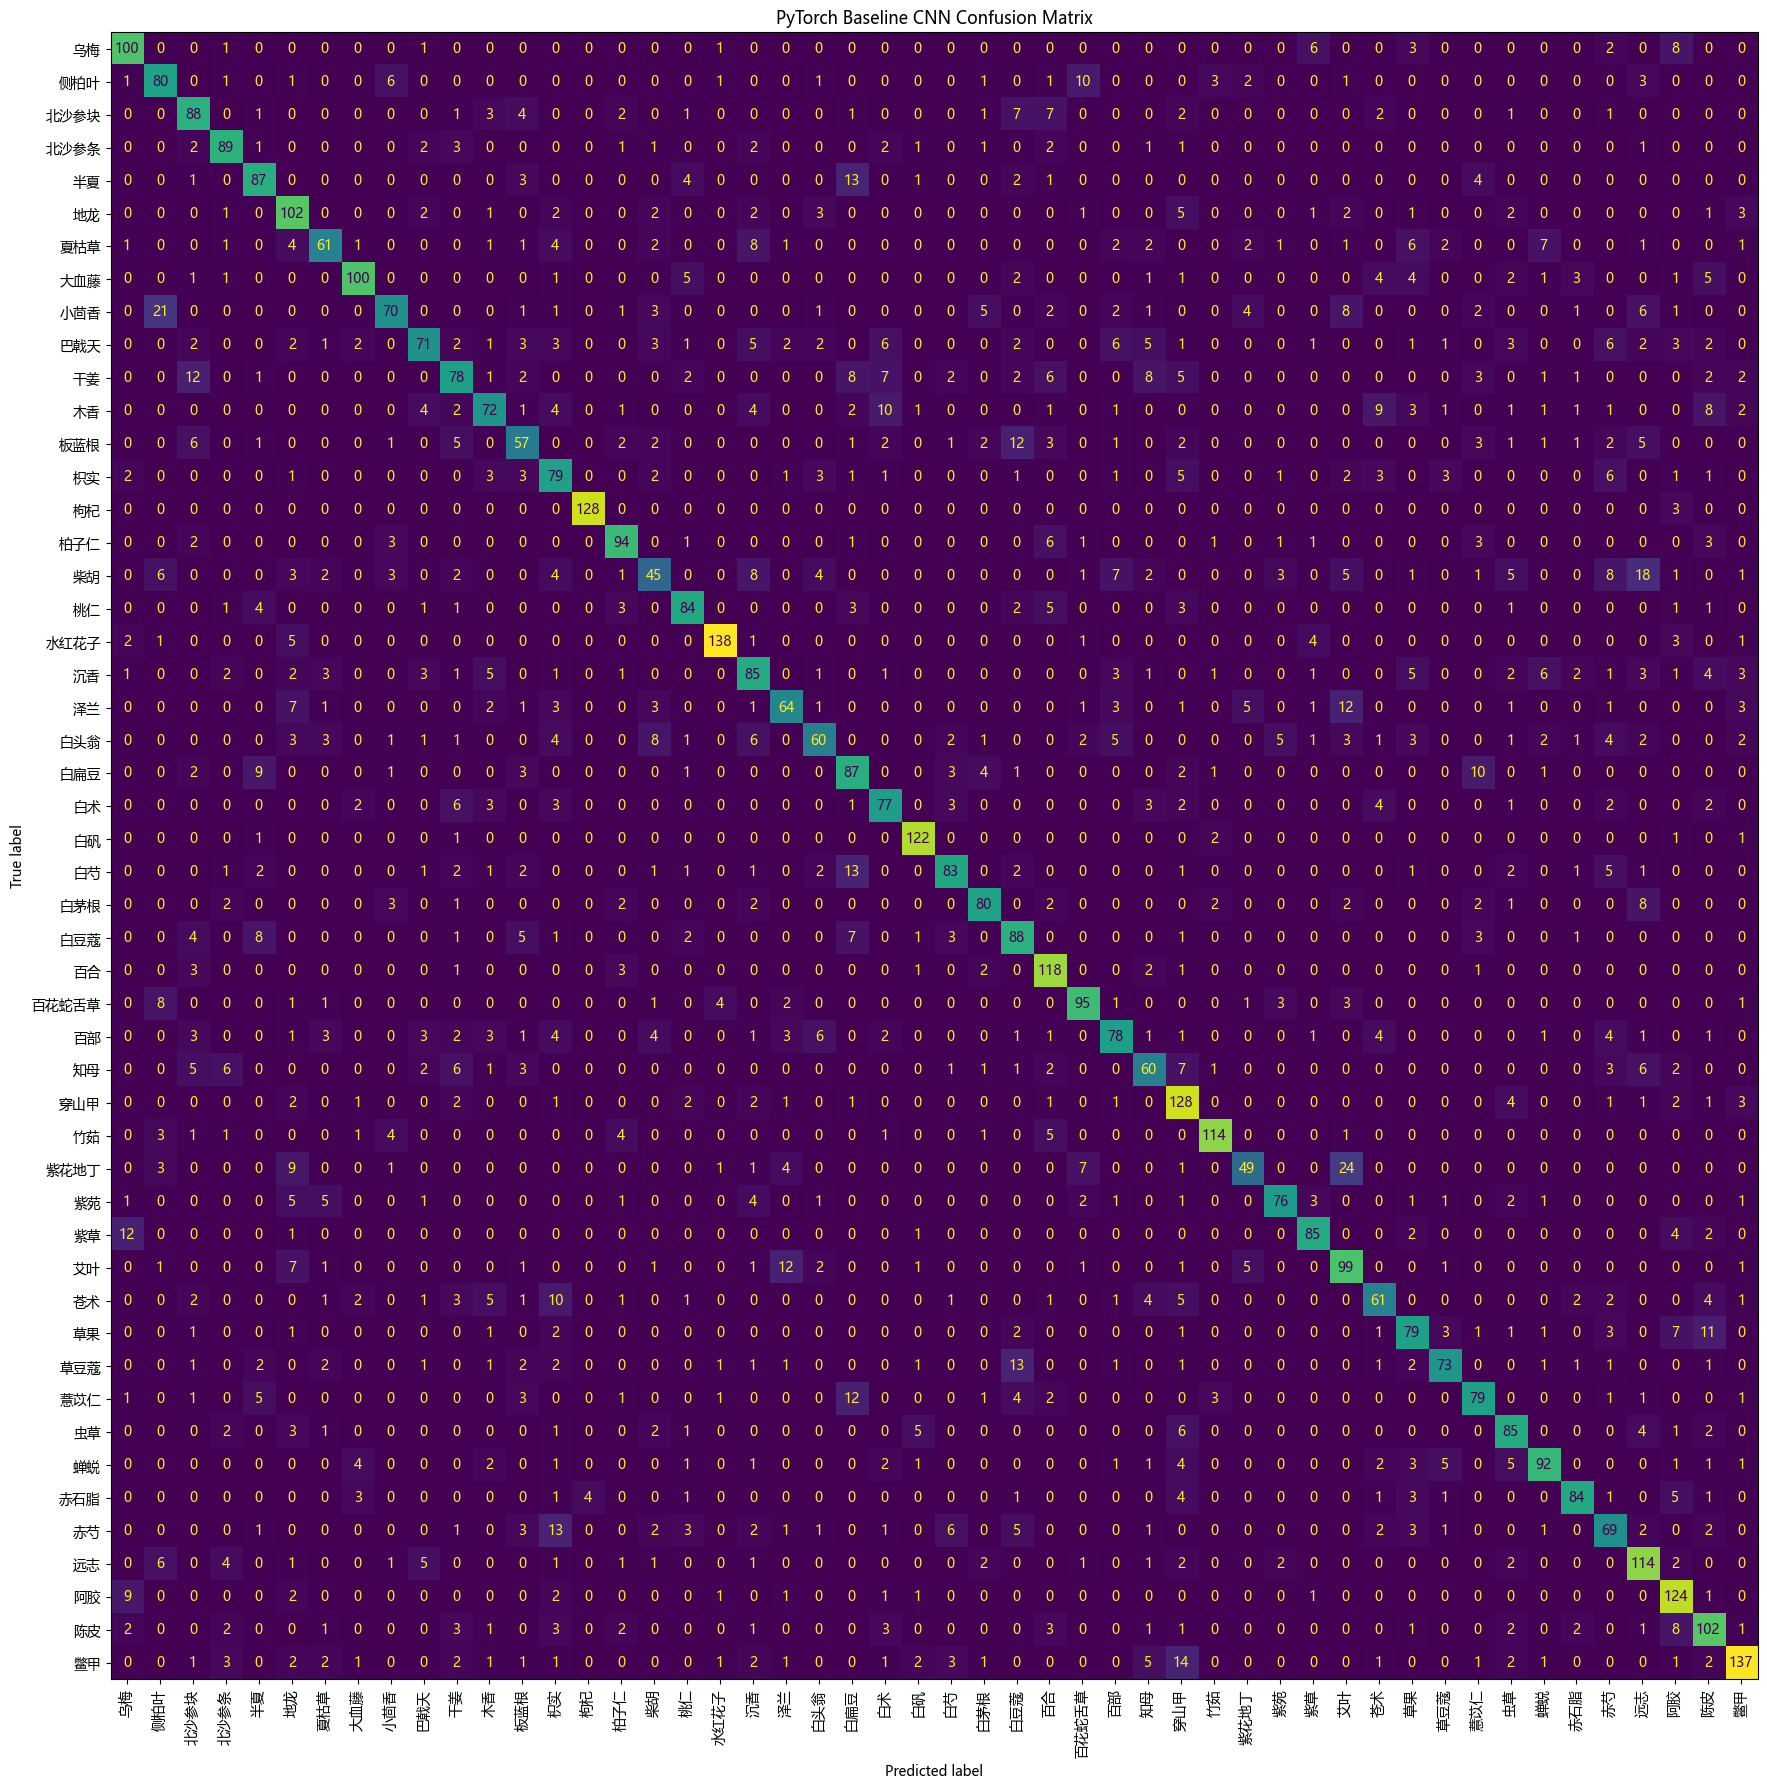

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\baseline_cnn_pytorch_confusion_matrix.png


In [25]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("PyTorch Baseline CNN Confusion Matrix")
plt.tight_layout()

cm_fig_path = FIGURES_DIR / "baseline_cnn_pytorch_confusion_matrix.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", cm_fig_path)

In [26]:
# Save a summary json
summary = {
    "model_name": "baseline_cnn_pytorch",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history["train_loss"]),
    "learning_rate": LEARNING_RATE,
    "num_classes": num_classes,
    "best_val_accuracy": float(max(history["val_acc"])),
    "best_val_loss": float(min(history["val_loss"])),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "device": str(device)
}

summary_path = REPORTS_DIR / "baseline_cnn_pytorch_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=4)

print("Saved:", summary_path)
summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\baseline_cnn_pytorch_summary.json


{'model_name': 'baseline_cnn_pytorch',
 'image_size': 128,
 'batch_size': 32,
 'epochs_requested': 10,
 'epochs_completed': 10,
 'learning_rate': 0.001,
 'num_classes': 50,
 'best_val_accuracy': 0.6843880501124318,
 'best_val_loss': 1.1051913995069589,
 'test_loss': 1.0598999256882649,
 'test_accuracy': 0.7012195121951219,
 'device': 'cuda'}

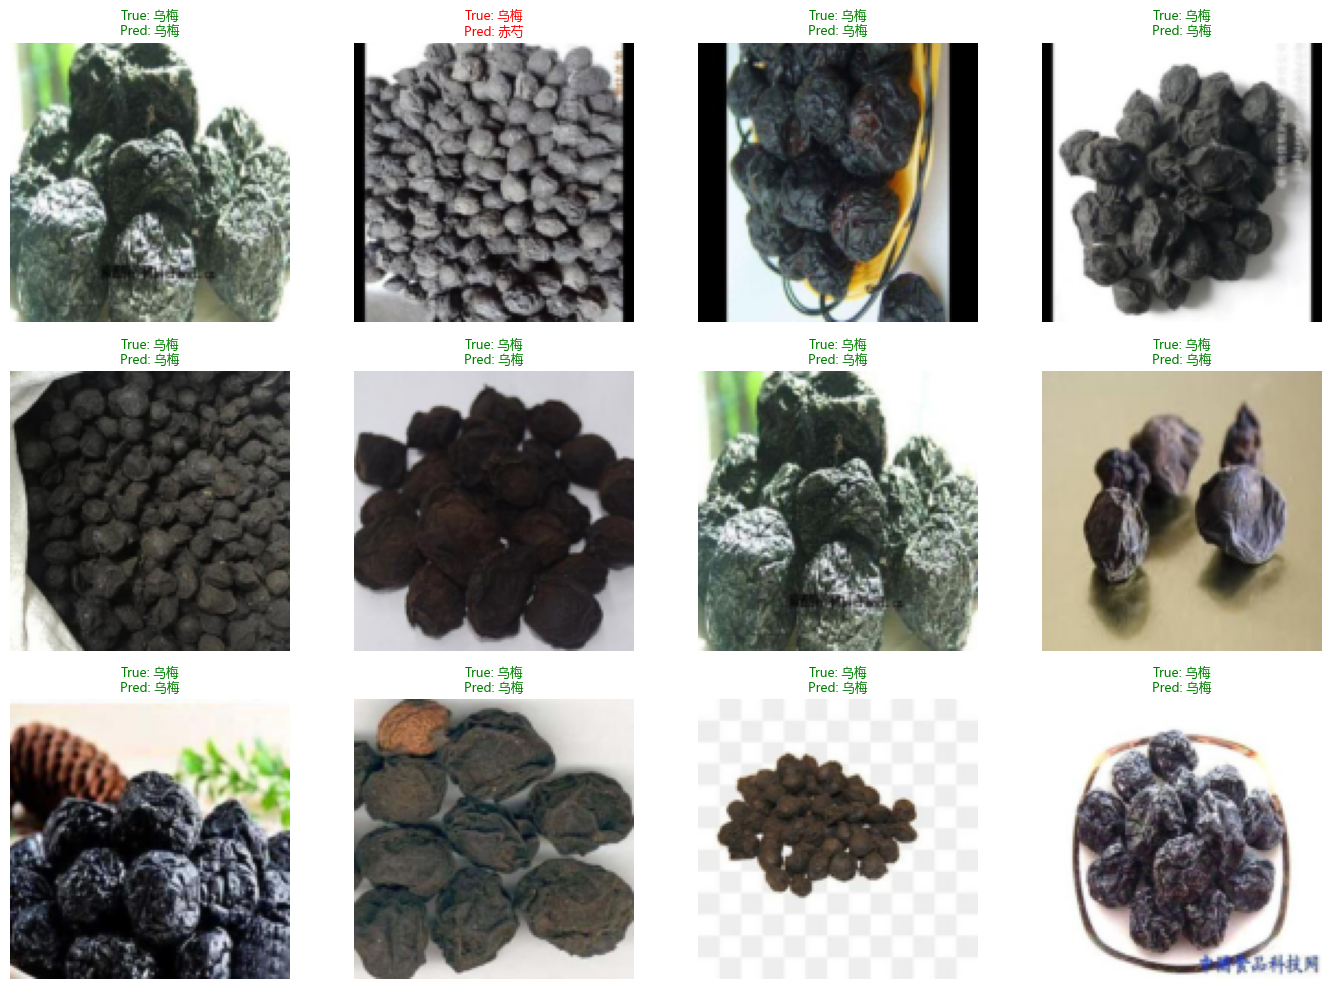

In [27]:
# Show a few test predictions
model.eval()

sample_images = []
sample_true = []
sample_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(min(len(images), 12 - len(sample_images))):
            img_np = images[i].cpu().permute(1, 2, 0).numpy()
            sample_images.append(img_np)
            sample_true.append(class_names[labels[i].item()])
            sample_pred.append(class_names[preds[i].item()])

        if len(sample_images) >= 12:
            break

plt.figure(figsize=(14, 10))
for i in range(len(sample_images)):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(sample_images[i])
    color = "green" if sample_true[i] == sample_pred[i] else "red"
    plt.title(f"True: {sample_true[i]}\nPred: {sample_pred[i]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Notes for report writing

You can describe this notebook as:
- A **baseline CNN built from scratch**
- Framework: **PyTorch**
- Input size: **128 × 128**
- Optimizer: **Adam**
- Loss: **CrossEntropyLoss**
- Regularization: **dropout**
- Learning-rate strategy: **ReduceLROnPlateau**
- Training control: **early stopping by patience**

This notebook gives the first benchmark before trying a stronger transfer learning model.
